# Task 2: Classificatore SVM Lineare su Feature Linguistiche Non Lessicali

Questo notebook implementa un sistema di classificazione basato su caratteristiche linguistiche avanzate (estratte tramite strumenti di NLP e basate sullo schema *Universal Dependencies*). A differenza del Task 1, l'addestramento della **Support Vector Machine (SVM)** non si basa sulle parole o sui caratteri (lessico), bensì su feature stilometriche, morfosintattiche e di complessità sintattica (*Profiling Linguistico*).

In [1]:
import os
import warnings
import numpy as np
import pandas as pd

from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Disattiviamo i warning di frammentazione di Pandas
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

## 1. Caricamento dei Dataset di Supporto

Prima di elaborare i vettori di profili linguistici, carichiamo i dati originali preprocessati per recuperare i testi e le etichette reali (`label`).

In [2]:
df_train = pd.read_pickle("../data/processed/df_train_processed.pkl")
df_val = pd.read_pickle("../data/processed/df_val_processed.pkl")
df_test = pd.read_pickle("../data/processed/df_test_processed.pkl")

In [3]:
profiling_path = '../data/processed/data_task2/profiling_UD_all.csv'

## 2. Caricamento e Allineamento dei Profili Linguistici (UD Features)

I file CSV contengono centinaia di feature non lessicali associate ai documenti. Estraiamo il `doc_id` dal nome del file per ordinare i record e garantire un perfetto allineamento posizionale con le etichette dei dataset originari.

In [ ]:
def split_and_align_profiling(csv_path):
    """
    Carica il file TSV/CSV unico di Profiling-UD e lo divide in Train, Validation e Test.
    Estrae l'ID dal filename e ordina le righe per allinearle ai dataframe originali.
    """
    # 1. Caricamento del dataset unificato
    df_all = pd.read_csv(csv_path, delimiter='\t')

    # Funzione interna per processare i singoli split
    def extract_split(prefix):
        # Filtra le righe in base al prefisso (es. "train_")
        df_subset = df_all[df_all['Filename'].str.startswith(prefix)].copy()
        
        # Estrae l'indice numerico (es. da "train_15.txt" estrae 15)
        doc_ids = df_subset['Filename'].str.extract(r'(\d+)')[0].astype(int)
        df_subset.insert(0, 'doc_id', doc_ids)
        
        # Ordina per ID, imposta l'indice e scarta la colonna Filename
        df_subset = df_subset.sort_values(by='doc_id').set_index('doc_id')
        return df_subset.drop(columns=['Filename'])

    # 2. Generazione delle tre matrici
    X_train = extract_split('train_')
    X_val = extract_split('val_')
    X_test = extract_split('test_')
    
    return X_train, X_val, X_test

# --- UTILIZZO ---

# Inserisci il percorso del file unico restituito da Profiling-UD
percorso_csv_unico = '../data/processed/data_task2/profiling_UD_all.csv' # Sostituisci col nome reale

X_train_ud, X_val_ud, X_test_ud = split_and_align_profiling(profiling_path)

# Le label rimangono le stesse dei tuoi dataframe originali
y_train_ud = df_train['label'].copy()
y_val_ud = df_val['label'].copy()
y_test_ud = df_test['label'].copy()

print(f"Numero esatto di feature estratte: {X_train_ud.shape[1]}")
print(f"Dimensioni Train: {X_train_ud.shape}")
print(f"Dimensioni Validation: {X_val_ud.shape}")
print(f"Dimensioni Test: {X_test_ud.shape}")

4000
Numero esatto di feature estratte: 142
Dimensioni Train: (2000, 142)
Dimensioni Validation: (1000, 142)
Dimensioni Test: (1000, 142)


## 3. Definizione della Pipeline e Valutazione delle Performance

Poiché le feature linguistiche hanno scale e unità di misura molto eterogenee (es. conteggi assoluti vs densità lessicale), utilizziamo uno **StandardScaler** prima di alimentare il classificatore **LinearSVC**. 
Valutiamo il comportamento del modello sia sul Validation Set che sul Test Set indipendente.

Modello Baseline (LinearSVC di default)

Addestriamo una SVM lineare con i parametri di default (C=1.0). Includiamo anche la predizione sul Training Set per monitorare eventuali fenomeni di overfitting.

In [13]:
# Definizione della pipeline (Default C=1.0)
model_ud_baseline = Pipeline([
    ("scaler", StandardScaler()),  
    ("clf", LinearSVC(random_state=42, max_iter=10000))  
])

# Addestramento
model_ud_baseline.fit(X_train_ud, y_train_ud)

# Predizioni (Train, Val, Test)
pred_train_baseline = model_ud_baseline.predict(X_train_ud)
pred_val_baseline = model_ud_baseline.predict(X_val_ud)
pred_test_baseline = model_ud_baseline.predict(X_test_ud)

# Report
print("=== TRAINING SET REPORT (C=1.0) ===")
print(classification_report(y_train_ud, pred_train_baseline, zero_division=0))
print("\n=== VALIDATION SET REPORT (C=1.0) ===")
print(classification_report(y_val_ud, pred_val_baseline, zero_division=0))
print("\n=== TEST SET REPORT (C=1.0) ===")
print(classification_report(y_test_ud, pred_test_baseline, zero_division=0))

=== TRAINING SET REPORT (C=1.0) ===
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1000
           1       0.98      0.98      0.98      1000

    accuracy                           0.98      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       0.98      0.98      0.98      2000


=== VALIDATION SET REPORT (C=1.0) ===
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       500
           1       0.94      0.94      0.94       500

    accuracy                           0.94      1000
   macro avg       0.94      0.94      0.94      1000
weighted avg       0.94      0.94      0.94      1000


=== TEST SET REPORT (C=1.0) ===
              precision    recall  f1-score   support

           0       0.84      0.93      0.88       500
           1       0.92      0.82      0.87       500

    accuracy                           0.88      1000
   macro avg       0

Ottimizzazione: Regolarizzazione della SVM

Per mitigare l'overfitting osservato sul Training Set (Macro F1 = 0.98 vs Test F1 = 0.88), proviamo a incrementare la regolarizzazione del modello abbassando l'iperparametro C a 0.1.

In [12]:
# Definizione della pipeline di modellazione
model_ud = Pipeline([
    ("scaler", StandardScaler()),  
    #("clf", LinearSVC(random_state=42, max_iter=10000))  
    ("clf", LinearSVC(C=0.1, random_state=42, max_iter=10000))
# oppure C=0.01
])

# Addestramento sui dati del profilo linguistico
model_ud.fit(X_train_ud, y_train_ud)

# 1. GENERIAMO LE PREDIZIONI ANCHE SUL TRAIN SET
pred_train_ud = model_ud.predict(X_train_ud)
pred_val_ud = model_ud.predict(X_val_ud)
pred_test_ud = model_ud.predict(X_test_ud)

# 2. STAMPA DEI REPORT PER IL CONFRONTO
print("=== TRAINING SET REPORT (Profiling-UD) ===")
print(classification_report(y_train_ud, pred_train_ud, zero_division=0))

print("\n=== VALIDATION SET REPORT (Profiling-UD) ===")
print(classification_report(y_val_ud, pred_val_ud, zero_division=0))

print("\n=== TEST SET REPORT (Profiling-UD) ===")
print(classification_report(y_test_ud, pred_test_ud, zero_division=0))

=== TRAINING SET REPORT (Profiling-UD) ===
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1000
           1       0.97      0.97      0.97      1000

    accuracy                           0.97      2000
   macro avg       0.97      0.97      0.97      2000
weighted avg       0.97      0.97      0.97      2000


=== VALIDATION SET REPORT (Profiling-UD) ===
              precision    recall  f1-score   support

           0       0.95      0.94      0.94       500
           1       0.94      0.95      0.95       500

    accuracy                           0.94      1000
   macro avg       0.95      0.94      0.94      1000
weighted avg       0.95      0.94      0.94      1000


=== TEST SET REPORT (Profiling-UD) ===
              precision    recall  f1-score   support

           0       0.84      0.93      0.88       500
           1       0.92      0.83      0.87       500

    accuracy                           0.88      1000

## 4. Analisi dell'Incertezza: i 5 Casi più Ambigui

Sfruttando la funzione `decision_function` di SVM, calcoliamo la distanza geometrica dei campioni del Test Set dall'iperpiano di decisione. Minore è la distanza in valore assoluto, maggiore è l'incertezza del modello sul documento.

In [7]:
# Calcolo delle distanze dal confine di decisione
distanze = model_ud.decision_function(X_test_ud)

# Costruzione del DataFrame per il tracciamento dell'incertezza
df_incertezza = pd.DataFrame({
    'distanza_assoluta': np.abs(distanze),
    'distanza_reale': distanze,
    'testo': df_test['text'],
    'label_reale': y_test_ud,
    'predizione': pred_test_ud
})

# Isola le 5 istanze più vicine allo zero (i casi più ambigui)
i_5_più_incerti = df_incertezza.sort_values(by='distanza_assoluta').head(5)

# Visualizzazione pulita dei casi critici
i_5_più_incerti[['distanza_reale', 'label_reale', 'predizione', 'testo']]

,distanza_reale,label_reale,predizione,testo
411,-0.006234,1,0,"Una qualificazione che, francamente, lascia un..."
539,-0.007533,0,0,"Culle di pelliccia, quindi, amiche del respiro..."
620,0.014163,1,1,"Una cifra considerevole, che si somma a quelle..."
666,-0.033596,1,0,"According to Amnesty, sino al 2023 sarebbero s..."
60,0.034139,0,1,Ma il trauma rimane. A prendere di mira la tur...


In [8]:
for row in i_5_più_incerti[['testo', 'label_reale']].itertuples(index=False):
    print(f'{row.label_reale}: {row.testo}')

1: Una qualificazione che, francamente, lascia un po’ di amaro in bocca. Non per la prestazione del Feyenoord, squadra solida e mai doma, ma per quella dei giallorossi. Si avvertiva la tensione, il peso di un match decisivo, e la Roma, pur giocando tra le mura amiche, ha faticato a imporre il proprio gioco. Troppo compassati, a tratti rinchiusi nella propria metà campo, i ragazzi di De Rossi hanno concesso fin troppo spazio agli olandesi, rischiando più di quanto vorrebbe la prudenza. Un rigore trasformato da Paulo Dybala, un lampo di genio in una notte grigia, ha fatto la differenza, ma senza quella sterilità offensiva che pure si è vista in più occasioni. Qualcuno parlerà di cinismo, di gestione del vantaggio, di esperienza nel saper soffrire. Ma noi crediamo che ci sia altro da sottolineare. Questa Roma ha bisogno di maggiore personalità, di un’identità più definita, di un coraggio che vada oltre il risultato. Si è visto un passo avanti rispetto al passato, certo, l’impronta di De R

## 5. Interpretabilità del Modello: Feature Dominanti

Un grande vantaggio delle SVM con kernel lineare è l'ispezionabilità dei coefficienti (`coef_`). I pesi positivi spingono la classificazione verso la classe target (1), mentre i pesi negativi verso la classe di controllo (0). Vediamo le **20 caratteristiche linguistiche più determinanti** in valore assoluto.

In [9]:
# Estrazione dei coefficienti assegnati dal classificatore lineare
pesi = model_ud['clf'].coef_[0]

df_feature_importanti = pd.DataFrame({
    'Feature': X_train_ud.columns,
    'Peso': pesi,
    'Peso_Assoluto': np.abs(pesi)
})

# Ordinamento in base all'importanza globale (valore assoluto)
le_20_dominanti = df_feature_importanti.sort_values(by='Peso_Assoluto', ascending=False).head(20)
le_20_dominanti[['Feature', 'Peso']].reset_index(drop=True)

,Feature,Peso
0,n_tokens,-2.419550
1,dep_dist_advmod,1.874887
2,upos_dist_ADV,-1.525562
3,lexical_density,-1.457216
4,n_prepositional_chains,1.309277
5,ttr_form_chunks_200,-1.297199
6,dep_dist_det,-1.232555
7,upos_dist_NUM,-1.121208
8,upos_dist_PUNCT,1.016788
9,upos_dist_PRON,-0.999782


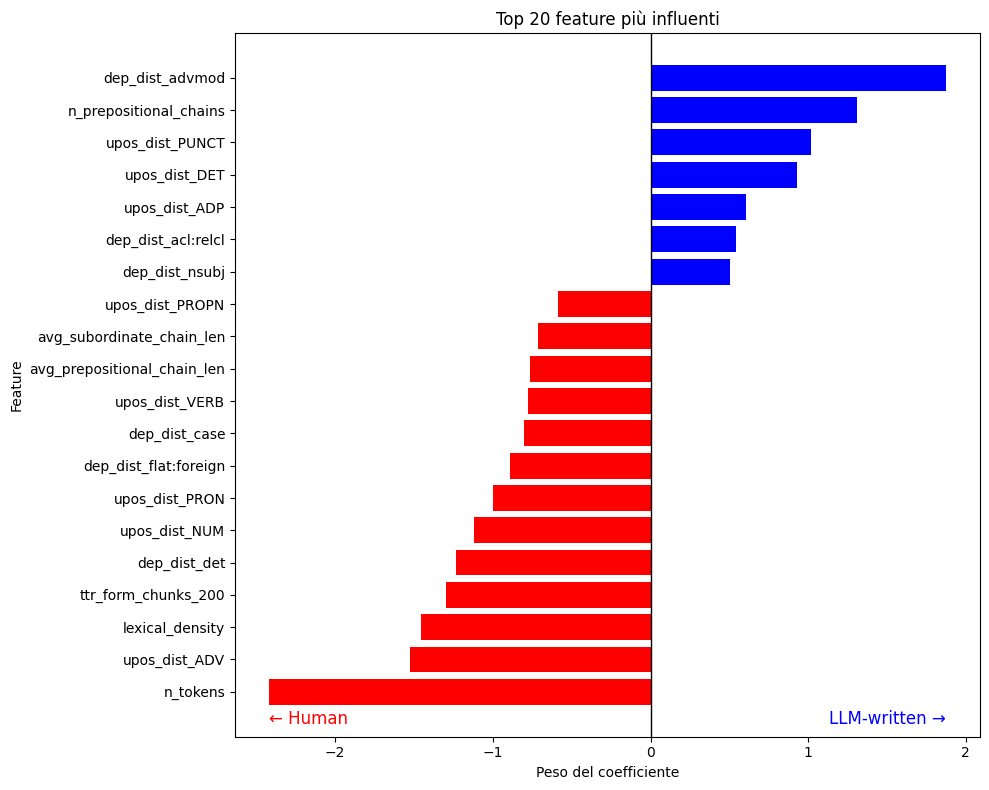

In [10]:
# Coefficienti del classificatore
pesi = model_ud['clf'].coef_[0]

# DataFrame feature
df_feature_importanti = pd.DataFrame({
    'Feature': X_train_ud.columns,
    'Peso': pesi,
    'Peso_Assoluto': np.abs(pesi)
})

# Top 20 feature più influenti
top_20 = (
    df_feature_importanti
    .sort_values(by='Peso_Assoluto', ascending=False)
    .head(20)
)

# Ordina per plotting
top_20 = top_20.sort_values(by='Peso')

# Colori:
# rosso -> human
# blu -> llm-written
colori = ['red' if x < 0 else 'blue' for x in top_20['Peso']]

# Plot
plt.figure(figsize=(10, 8))

plt.barh(
    top_20['Feature'],
    top_20['Peso'],
    color=colori
)

# Linea centrale
plt.axvline(0, color='black', linewidth=1)

plt.xlabel('Peso del coefficiente')
plt.ylabel('Feature')
plt.title('Top 20 feature più influenti')

# Annotazioni interpretative
plt.text(
    top_20['Peso'].min(),
    -1,
    '← Human',
    fontsize=12,
    color='red'
)

plt.text(
    top_20['Peso'].max(),
    -1,
    'LLM-written →',
    fontsize=12,
    color='blue',
    ha='right'
)

plt.tight_layout()
plt.show()

### 💡 Analisi dei Pattern Linguistici Rilevati

Dall'estrazione delle feature dominanti emergono considerazioni interessanti sulla struttura dei testi:
* **Feature con peso negativo importante (es. `n_tokens`, `upos_dist_ADV`, `lexical_density`)**: Indicano che i testi più lunghi, con una forte presenza di avverbi e un'alta densità lessicale, sono associati dal modello alla **Classe 0**.
* **Feature con peso positivo importante (es. `dep_dist_advmod`, `n_prepositional_chains`)**: Pattern legati a costrutti sintattici più stratificati o modificatori avverbiali guidano il modello verso l'assegnazione della **Classe 1**.

Rispetto al Task 1 basato su n-grammi di caratteri, questo modello mostra una stabilità decisamente superiore e una minor perdita di performance nel passaggio dal Validation al Test set (da **0.95** a **0.88** di F1-macro), provando l'efficacia e la robustezza delle feature non lessicali contro i rischi di domain shift.